In [4]:
%matplotlib inline
import seaborn as sns
import os
import sys
import subprocess
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
from pyarrow import fs
import pyarrow.parquet as pq
import pandas as pd
import numpy as np

os.environ["HADOOP_CONF_DIR"] = "/path/to/hadoop/conf/"
os.environ["JAVA_HOME"] = "/path/to/java"
os.environ["HADOOP_HOME"] = "/path/to/hadoop"
os.environ["ARROW_LIBHDFS_DIR"] = "/path/to/hadoop/lib/"
os.environ["CLASSPATH"] = subprocess.check_output(
    "$HADOOP_HOME/bin/hadoop classpath --glob", shell=True
).decode("utf-8")

hdfs = fs.HadoopFileSystem(
    host="hdfs://your-hdfs-host", port=8020
)

# import pandas as pd
from tqdm import tqdm
import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning

warnings.simplefilter('ignore', ConvergenceWarning)
import sys

if not sys.warnoptions:
    import warnings

    warnings.simplefilter("ignore")

import logging

logging.getLogger("prophet").setLevel(logging.WARNING)
logging.getLogger("cmdstanpy").disabled = True

df_total = pd.read_parquet(
    "/path/to/company_data/sa/cpc/store/data/SUM_TOTAL/total_sl_13_provinces.parquet",
    filesystem=hdfs, )
df_total.sort_index(ascending=False).head()
# df_total = df_total[df_total.index<'2023-7-1']


,BDINH,DANANG,DLAC,DNONG,GLAI,KHOA,KTUM,PYEN,QBINH,QNAM,QNGAI,QTRI,TTHUE,Month,Year
2023-09-01,245839910,334853775,176063087,54283312,110191783,260444740,43581322,100937390,98962439,236474490,204920013,77906522,178190905,9,2023
2023-08-01,242369036,343785390,165399531,56374080,102936424,265528697,41840936,102246544,110525322,240610425,215246731,76453922,199127317,8,2023
2023-07-01,233235735,326926273,225670967,54001966,99612551,257294123,35742815,98088703,113621328,235488889,208611398,76141968,198830608,7,2023
2023-06-01,228823421,330680715,168812969,53316010,107390568,271509827,36895142,96097851,110674072,227709151,194811747,76724152,195177149,6,2023
2023-05-01,216806344,286066168,187140663,60349930,117451433,247772333,38467958,92300982,94728487,218021212,199729737,66608424,175060653,5,2023


In [6]:
df_profile = pd.read_parquet(
    "/path/to/company_data/user/<user>/CPC/profile_CPC",
    filesystem=hdfs, )
df_code = pd.read_parquet('/path/to/company_data/sa/cpc/store/data/SUM_TOTAL/df_dvi.parquet',filesystem=hdfs)

In [7]:
df_sl_13province = pd.DataFrame()
for year in range(2014,2025):
    df_each_year = pd.read_parquet("/path/to/company_data/user/<user>/CPC/SL_MDD_1M.parquet/Y={}".format(year),
                                   filesystem=hdfs)
    df_each_year['year'] = year
    print(df_each_year.shape)
    df_sl_13province = pd.concat([df_sl_13province,df_each_year],axis=0)
    # break
df_sl_13province['date'] = df_sl_13province.apply(lambda row: f"{row['year']}-{row['M']}-1",axis=1)
df_sl_13province['date'] = pd.to_datetime(df_sl_13province['date'])

df_total = df_sl_13province.merge(df_profile[['MA_DDO','U']],on='MA_DDO',how='left')
df_code.columns = ['PROVINCE', 'U', 'DVI_VN', 'DVI_FULL', 'UPDATE_DATE']
df_total = df_total.merge(df_code[['U','PROVINCE']],on='U',how='left')
df_total = df_total.drop(8342)
df_total = df_total[df_total['SLUONG_FINAL'] > 0]

(9307, 13)
(10498, 13)
(11900, 13)
(13273, 13)
(14744, 13)
(16408, 13)
(17825, 13)
(18868, 13)
(19212, 13)
(20076, 13)
(1666, 13)


In [17]:
! hdfs dfs -ls /path/to/company_data/user/<user>/cpc/

Found 3 items
drwxrwx---+  - <user> fdp          0 2023-10-06 14:56 /path/to/company_data/user/<user>/cpc/data
drwxrwx---+  - <user> fdp          0 2024-02-22 11:26 /path/to/company_data/user/<user>/cpc/predict
drwxrwx---+  - <user> fdp          0 2023-10-07 08:58 /path/to/company_data/user/<user>/cpc/result


In [18]:
df_total.to_parquet('/path/to/company_data/user/<user>/cpc/data/data_1M_012024.parquet',filesystem=hdfs)

In [26]:
df_dims = df_total.groupby('MA_DDO').agg(PROVINCE=('PROVINCE','max')).reset_index()

In [28]:
df_dims.columns = ['restaurant_id','city']

In [29]:
df_dims.to_parquet('/path/to/company_data/user/<user>/cpc/data/dims_1M_012024.parquet',filesystem=hdfs)

<AxesSubplot: xlabel='date'>

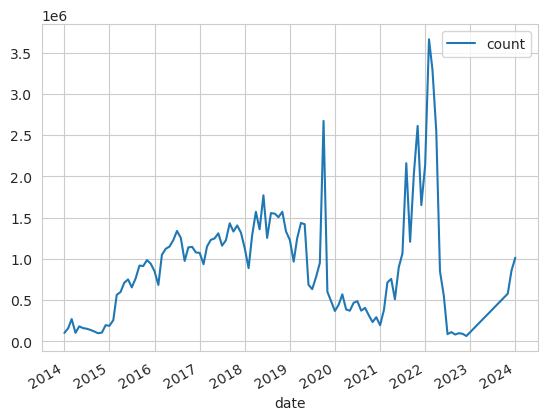

In [136]:
df_total[df_total['U'].isna()].groupby('date').agg(count=('SLUONG_FINAL','sum')).plot()

In [137]:
df_total = df_total.pivot_table(index='date',columns='PROVINCE',values='SLUONG_FINAL',aggfunc='sum')


In [138]:
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.seasonal import STL
from prophet import Prophet
import pandas as pd
from pmdarima import auto_arima


def measure_simility(arr1, arr2):
    arr1 = arr1.reshape((-1,))
    arr2 = arr2.reshape((-1,))
    score = np.corrcoef(arr1, arr2)[0, 1]
    return score


def pick_data_train(vt, arrs, n):
    score = []
    for arr in arrs:
        score.append(measure_simility(vt, arr))
    score = np.array(score)
    return np.argsort(score)[-n:], score[np.argsort(score)[-n:]]


def create_data_total(df, month, year, lag, shift):
    x_knowns = df[df.index < year].iloc[:, 11 + month - lag - shift: 11 + month - shift].values.reshape((-1, lag))
    # y_known = df[df.index == year].iloc[0,11 + month-lag: 11 +month].values
    y_known = df[df.index == year].iloc[0, 11 + month - lag: 11 + month].values
    # y_known = df.iloc[-1, 11 + month - lag: 11 + month].values
    x_news = df[df.index < year].iloc[:, 11 + month - shift].values
    # print(month,year,y_known)
    return x_knowns, y_known, x_news


def create_data_cumsum(df, month, year, lag, shift):
    x_knowns = df[df.index < year].iloc[:, 11 + month - lag - shift: 11 + month - shift].cumsum(axis=1).values.reshape(
        (-1, lag))
    y_known = df[df.index == year].iloc[:, 11 + month - lag: 11 + month].cumsum(axis=1).iloc[0, :].values
    # y_known = df.iloc[[-1], 11 + month - lag: 11 + month].cumsum(axis=1).iloc[0, :].values
    x_news = df[df.index < year].iloc[:, 11 + month - lag - shift: 12 + month - shift].cumsum(axis=1).iloc[:, -1].values
    return x_knowns, y_known, x_news


def create_data_rolling(df, month, year, lag, shift, n_rolling):
    y_old = df[df.index == year].iloc[0, 11 + month - 1 - n_rolling + 1:11 + month - 1].sum()
    df = df.rolling(n_rolling, axis=1).mean()
    x_knowns = df[df.index < year].iloc[:, 11 + month - lag - shift: 11 + month - shift].values.reshape((-1, lag))
    y_known = df[df.index == year].iloc[0, 11 + month - lag: 11 + month].values
    x_news = df[df.index < year].iloc[:, 11 + month - shift].values
    return x_knowns, y_known, x_news, y_old


def predict_total(known_y, known_x, new_x, order):
    # known_y = known_y.reshape((-1,))
    # known_x = known_x.reshape((-1,))
    coefficients = np.polyfit(known_x, known_y, order)
    estimated_func = np.poly1d(coefficients)
    return float(estimated_func(new_x))


def predict_cumsum(known_y, known_x, new_x, order):
    # known_y = known_y.reshape((-1,))
    # known_x = known_x.reshape((-1,))
    coefficients = np.polyfit(known_x, known_y, order)
    estimated_func = np.poly1d(coefficients)
    return float(estimated_func(new_x))


def predict(df_total, year, month: int, lag: int, order1: int, order2: int, shift: int, n_max):
    x_knowns, y_known, x_news = create_data_total(df_total, month, year, lag, shift)
    max_scores, coeffs = pick_data_train(y_known, x_knowns, n_max)
    pre = []
    for max_score in max_scores:
        x_knowns, y_known, x_news = create_data_total(df_total, month, year, lag, shift)
        x_known = x_knowns[max_score]
        x_new = x_news[max_score]

        pred1 = predict_total(known_y=y_known,
                              known_x=x_known,
                              new_x=x_new, order=order1)
        pre.append(pred1)
        shift = 0
        x_knowns, y_known, x_news = create_data_cumsum(df_total, month, year, lag, shift)
        x_known = x_knowns[max_score]
        x_new = x_news[max_score]
        pred2 = predict_cumsum(known_y=y_known,
                               known_x=x_known,
                               new_x=x_new, order=order2) - y_known[-1]

        pre.append(pred2)
    return np.mean(pre), coeffs.mean()


def predict_master(data: pd.DataFrame, d_date: pd.DataFrame, month, year, lag, p, d, q, n_max, type_decomp,
                   methods_season, method_resid, method_trend,order1,order2):
    date = f"{year}-{month}-1"
    # print(date)
    # d_train = data[data.index < f"{year}-1-1"]
    d_train = data[data.index < date]
    d_train = pd.concat([d_train, d_date], axis=1).dropna(axis=0)

    d_residuals, d_trend, d_seasonal = detrend(d_train, type=type_decomp)
    # y_residual=0
    y_residual = forecast_residual(d_residuals.values, p, d, q, method_resid=method_resid)
    # except:
    #     y_residual = 0

    d_seasonal.name = name_province
    # d_seasonal = pd.concat([d_seasonal, d_date], axis=1)
    d_seasonal = pd.concat([d_seasonal, d_date], axis=1).fillna(0)
    d_seasonal = d_seasonal.pivot_table(columns='month', index='year', values=name_province)
    y_seasonal = forecast_seasonal(d_seasonal, month, year, lag, n_max,order1,order2, methods_season)

    d_trend.name = name_province
    d_trend = pd.concat([d_trend, d_date], axis=1).dropna()
    try:
        d_trend_t2 = d_trend.iloc[-2, 0]
    except:
        d_trend_t2 = 0
    try:
        d_trend_t1 = d_trend.iloc[-1, 0]
    except:
        d_trend_t1 = 0

    y_trend = forecast_trend(d_trend_t2,d_trend_t1, method_trend=method_trend)

    # d_residuals = pd.concat([d_residuals, d_date], axis=1).dropna()
    # y_re3 = d_seasonal.pivot_table(columns='month', index='year', values=name_province).dropna(axis=0).mean(axis=0)[
    #     month]
    # d_residuals = d_residuals.pivot_table(columns='month', index='year', values=name_province)
    # d_trend = d_trend.pivot_table(columns='month', index='year', values=name_province)
    # y_re2 = forecast_seasonal(d_trend, month, year, lag, 2)
    # return y_lr + (y_re1 +y_re2+y_re)/3,y_re
    # return (y_re3 + y_re1) / 2 + y_re2
    return y_trend, y_seasonal, y_residual


def detrend(df: pd.DataFrame, type='STL'):
    if type == 'STL':
        data = df.copy()
        data = data.iloc[:, 0]
        stl = STL(data,period=12)
        res = stl.fit()
        trend = res.trend
        resid = res.resid
        season = res.seasonal
        return resid, trend, season
    if type == 'prophet':
        data = df.copy()
        data = data.iloc[:, [0]]
        data = data.reset_index()
        data.columns = ['ds', 'y']
        model = Prophet(yearly_seasonality=12)
        model.fit(data)
        forecaster = model.predict(model.make_future_dataframe(periods=0, freq='MS'))
        forecaster['y'] = data['y']
        forecaster['resid'] = forecaster.apply(lambda row: (row.y - (row.yearly + row.trend)), axis=1)
        forecaster = forecaster.set_index('ds')
        df_resid = forecaster['resid']
        df_trend = forecaster['trend']
        df_season = forecaster['yearly']
        df_season.name = 'seasonal'
        return df_resid, df_trend, df_season
    else:
        return None, None, None


def compute_error(data, month, year, y_pr):
    y_tr = data[data.index == f'{year}-{month}-1'].values[0]
    return (y_pr - y_tr) / y_tr, y_tr


def forecast_seasonal(data, month, year, lag, n_max,order1,order2, method='statistics'):
    if method == 'statistics':
        df = data.copy()
        df = pd.concat([df.shift(1, axis=0), df, df.shift(-1, axis=0)], axis=1).iloc[1:, :] + 10e10
        # lag = int(params[month - 1][1])
        # shift = int(params[month - 1][2])
        # order1 = int(params[month - 1][3])
        # order2 = int(params[month - 1][4])
        # lag = 6
        shift = 0
        # order1 = 1
        # order2 = 1
        y, _ = predict(df, year, month, lag, order1, order2, shift, n_max)
        return y - 10e10
    if method == 'average':
        df = data.copy()
        # df = df[df.index<year]
        # print(df.dropna(axis=0).mean(axis=0))
        y = df.dropna(axis=0).mean(axis=0)[month]
        # print(y)
        return y
    if method == 'latest':
        df = data.copy()
        # df = df[df.index<year]
        # print(df.dropna(axis=0).mean(axis=0))
        y = df.dropna(axis=0).iloc[-1, :][month]
        # print(y)
        return y
    else:
        raise "Not specify the season method"


def forecast_trend(y_1, y_t, method_trend='average'):
    if method_trend == 'average':
        y_pr_trend = y_t + (y_t - y_1)
        # y_pr_trend = y_t
        return y_pr_trend
    if method_trend == 'latest':
        return y_t
    else:
        raise "Not specify the trend method"


def forecast_residual(series, p, d, q, method_resid='arima'):
    if method_resid == 'arima':
        try:
            model = ARIMA(series, order=(p, d, q))
            model_fit = model.fit()
            return model_fit.forecast(freq='MS')[0]
        except:return 0
    # if method_resid == 'autoarima':
    #     model = auto_arima(series, seasonal=False, trace=False)
    #     return model.predict(n_periods=1, freq='MS')[0]
    else:
        return 0


def get_ytr(df, month, year):
    try:
        filter = f'{year}-{month}-01'
        return df[df.index == filter].values[0][0]
    except:
        return None


In [139]:
df_datetime = pd.DataFrame({'stt': [i for i in range(df_total.shape[0])]},
                           index=df_total.sort_index(ascending=True).index)
df_datetime['month'] = df_datetime.index.month
df_datetime['year'] = df_datetime.index.year
df_datetime

,stt,month,year
date,,,
2014-01-01,0,1,2014
2014-02-01,1,2,2014
2014-03-01,2,3,2014
2014-04-01,3,4,2014
2014-05-01,4,5,2014
...,...,...,...
2023-09-01,116,9,2023
2023-10-01,117,10,2023
2023-11-01,118,11,2023


In [162]:
dfp = pd.read_parquet('/path/to/company_data/user/<user>/cpc/data/parameter/final_params_13province_u2023.parquet',filesystem=hdfs)
dfp

,province,n_max,lag,type_decomp,method_season,method_resid,method_trend,error_abs
0,BDINH,10,6,STL,statistics,None,average,0.081362
1,DANANG,10,6,STL,statistics,arima,average,0.066686
2,DLAC,10,6,STL,statistics,arima,average,0.198305
3,DNONG,5,6,STL,statistics,arima,average,0.246375
4,GLAI,5,8,STL,statistics,None,average,0.144923
5,KHOA,5,6,STL,statistics,arima,average,0.089738
6,KTUM,2,10,STL,statistics,None,average,0.128623
7,PYEN,5,6,STL,statistics,None,average,0.144254
8,QBINH,2,8,STL,statistics,None,average,0.141760
9,QNAM,10,6,STL,statistics,arima,average,0.066424


In [163]:
from tqdm import trange
# lst_pr = df_total.columns[:-2]
lst_pr = df_total.columns
df_result = pd.DataFrame()
lst_time_pr = pd.date_range(start='2022-1-1',end='2024-02-1',freq='MS').strftime('%Y-%m')

for n_province in trange(len(lst_pr)):
    df = df_total.iloc[:, [n_province]]
    name_province = lst_pr[n_province]
    df = df.sort_index()
    dp = dfp[dfp.province ==name_province]
    lag = 6
    # n_max = dp.n_max.values[0]
    type_decomp = dp.type_decomp.values[0]
    method_season =dp.method_season.values[0]
    method_trend =dp.method_trend.values[0]
    method_resid =dp.method_resid.values[0]
    n_max = 10
    # type_decomp = 'STL'
    # method_season='statistics'
    # method_trend='average'
    # method_resid='arima'
    p = 1
    d = 0
    q = 1
    for time_pr in lst_time_pr:
            year = int(time_pr.split('-')[0])
            month = int(time_pr.split('-')[1])
    # for year in years:
    #     for month in range(1, 3):
            # print(month)
            y_trend, y_seasonal, y_residual = predict_master(
                data=df,
                d_date=df_datetime,
                month=month, year=year,
                lag=lag, p=p, d=d, q=q,
                n_max=n_max,
                type_decomp=type_decomp,
                methods_season=method_season, method_resid=method_resid,
                method_trend=method_trend,order1=1,
                order2=1)

            y_pr = y_trend + y_seasonal + y_residual
            try:
                error, y_tr = compute_error(df, month, year, y_pr)
                df_result = pd.concat([df_result, pd.DataFrame(
                    {'n_max': n_max,
                     'province': name_province,
                     'year': year,
                     'month': month,
                     'y_pr': y_pr,
                     'y_tr': y_tr,
                     'error': error,
                     'error_abs': np.abs(error),
                     'y_trend': y_trend,
                     'y_seasonal': y_seasonal,
                     'y_residual': y_residual,
                     'lag': lag,
                     'p': p, 'd': d, 'q': q,
                     'type_decomp': type_decomp,
                     'method_season': method_season,
                     'method_resid': method_resid,
                     'method_trend': method_trend,
                     })])
            except:
                df_result = pd.concat([df_result, pd.DataFrame(
                    {'n_max': n_max,
                     'province': name_province,
                     'year': year,
                     'month': month,
                     'y_pr': y_pr,
                     'y_tr': [None],
                     'error': [None],
                     'error_abs': [None],
                     'y_trend': y_trend,
                     'y_seasonal': y_seasonal,
                     'y_residual': y_residual,
                     'lag': lag,
                     'p': p, 'd': d, 'q': q,
                     'type_decomp': type_decomp,
                     'method_season': method_season,
                     'method_resid': method_resid,
                     'method_trend': method_trend,
                     })])
                break


100%|██████████| 13/13 [00:24<00:00,  1.89s/it]


In [172]:
df_result[df_result['year']==2024]

,n_max,province,year,month,y_pr,y_tr,error,error_abs,y_trend,y_seasonal,y_residual,lag,p,d,q,type_decomp,method_season,method_resid,method_trend
0,10,BDINH,2024,1,5.815568e+07,70482988,-0.174898,0.174898,5.962839e+07,-1.472714e+06,0.000000e+00,6,1,0,1,STL,statistics,None,average
0,10,BDINH,2024,2,6.142688e+07,None,NaN,NaN,6.510461e+07,-3.677723e+06,0.000000e+00,6,1,0,1,STL,statistics,None,average
0,10,DANANG,2024,1,7.700027e+07,79815091,-0.035267,0.035267,8.494017e+07,-8.220761e+06,2.808625e+05,6,1,0,1,STL,statistics,arima,average
0,10,DANANG,2024,2,6.830422e+07,None,NaN,NaN,8.900699e+07,-2.247366e+07,1.770891e+06,6,1,0,1,STL,statistics,arima,average
0,10,DLAC,2024,1,2.863746e+07,32469579,-0.118022,0.118022,3.240134e+07,-3.869559e+06,1.056801e+05,6,1,0,1,STL,statistics,arima,average
0,10,DLAC,2024,2,3.088957e+07,None,NaN,NaN,3.225225e+07,-1.498352e+06,1.356728e+05,6,1,0,1,STL,statistics,arima,average
0,10,DNONG,2024,1,1.496026e+07,13374870,0.118535,0.118535,1.417604e+07,7.978576e+05,-1.363723e+04,6,1,0,1,STL,statistics,arima,average
0,10,DNONG,2024,2,1.416323e+07,None,NaN,NaN,1.366719e+07,6.013269e+05,-1.052842e+05,6,1,0,1,STL,statistics,arima,average
0,10,GLAI,2024,1,1.620780e+07,16141166,0.004128,0.004128,1.208959e+07,4.118216e+06,0.000000e+00,6,1,0,1,STL,statistics,None,average
0,10,GLAI,2024,2,1.443602e+07,None,NaN,NaN,1.322221e+07,1.213806e+06,0.000000e+00,6,1,0,1,STL,statistics,None,average


In [165]:
df = df_result.copy()

In [166]:
df = df[['province','year','month','y_pr','y_tr','error','error_abs']]
df.columns = ['MA_DDO','YEAR','MONTH','y_pr','y_tr','error','error_abs']

In [175]:
df

,MA_DDO,YEAR,MONTH,y_pr,y_tr,error,error_abs
0,BDINH,2022,1,5.996551e+07,58135306.0,0.031482,0.031482
1,BDINH,2022,2,5.492047e+07,48938665.0,0.122231,0.122231
2,BDINH,2022,3,6.288757e+07,67827147.0,-0.072826,0.072826
3,BDINH,2022,4,6.281064e+07,64932952.0,-0.032685,0.032685
4,BDINH,2022,5,6.047416e+07,62928497.0,-0.039002,0.039002
...,...,...,...,...,...,...,...
333,TTHUE,2023,10,5.028352e+07,52643747.0,-0.044834,0.044834
334,TTHUE,2023,11,5.177725e+07,48759521.0,0.061890,0.061890
335,TTHUE,2023,12,4.856671e+07,51019237.0,-0.048071,0.048071
336,TTHUE,2024,1,4.579504e+07,46543211.0,-0.016075,0.016075


In [168]:
df.to_parquet('/path/to/company_data/user/<user>/cpc/predict/pr_SL_MDD_1M_v3.parquet',filesystem=hdfs,index=False)

In [169]:
df = pd.read_parquet('/path/to/company_data/user/<user>/cpc/predict/pr_SL_MDD_1M_v3.parquet',filesystem=hdfs)
df.groupby(['YEAR','MONTH']).agg(y_pr=('y_pr','sum'),y_tr=('y_tr','sum'),error=('error','mean'),error_abs=('error_abs','mean'))

y_pr         y_tr     error  error_abs
YEAR MONTH                                                
2022 1      4.660411e+08  501086084.0 -0.038300   0.120000
     2      4.433436e+08  400276906.0  0.181777   0.195759
     3      4.795364e+08  480139207.0  0.021612   0.083075
     4      4.975056e+08  522868746.0 -0.029357   0.112986
     5      4.907524e+08  499022759.0  0.086642   0.187920
     6      5.247652e+08  502631073.0  0.044877   0.135887
     7      5.077612e+08  501116973.0 -0.011410   0.083897
     8      5.217098e+08  516604274.0 -0.036132   0.100866
     9      5.251994e+08  536691542.0 -0.075889   0.137726
     10     5.312333e+08  524558906.0 -0.027621   0.131999
     11     5.312649e+08  536282209.0 -0.001478   0.114002
     12     5.263600e+08  519557367.0  0.011655   0.061757
2023 1      5.119821e+08  392058659.0  0.434607   0.435853
     2      4.356663e+08  483335909.0 -0.085448   0.101121
     3      5.078625e+08  535866818.0 -0.057972   0.094168
     4      5.243227e+08  493879730.0  0.156529   0.200425
     5      5.027224e+08  510958147.0  0.085331   0.156190
     6      5.237643e+08  518931504.0  0.078119   0.120140
     7      5.249815e+08  520470467.0  0.025715   0.084998
     8      5.315152e+08  553890375.0 -0.076263   0.108451
     9      5.340803e+08  532037778.0 -0.008276   0.131543
     10     5.326958e+08  524808199.0 -0.038520   0.107949
     11     5.340389e+08  505622049.0  0.055301   0.084209
     12     5.165200e+08  518990514.0  0.001271   0.064817
2024 1      4.926432e+08  516081732.0 -0.055429   0.083587
     2      4.672416e+08          0.0       NaN        NaN

In [174]:
df

,MA_DDO,YEAR,MONTH,y_pr,y_tr,error,error_abs
0,BDINH,2022,1,5.996551e+07,58135306.0,0.031482,0.031482
1,BDINH,2022,2,5.492047e+07,48938665.0,0.122231,0.122231
2,BDINH,2022,3,6.288757e+07,67827147.0,-0.072826,0.072826
3,BDINH,2022,4,6.281064e+07,64932952.0,-0.032685,0.032685
4,BDINH,2022,5,6.047416e+07,62928497.0,-0.039002,0.039002
...,...,...,...,...,...,...,...
333,TTHUE,2023,10,5.028352e+07,52643747.0,-0.044834,0.044834
334,TTHUE,2023,11,5.177725e+07,48759521.0,0.061890,0.061890
335,TTHUE,2023,12,4.856671e+07,51019237.0,-0.048071,0.048071
336,TTHUE,2024,1,4.579504e+07,46543211.0,-0.016075,0.016075


In [170]:
df_result.groupby(['year','month']).agg(y_pr=('y_pr','sum'),y_tr=('y_tr','sum'),error=('error','mean'),error_abs=('error_abs','mean'))

y_pr       y_tr     error  error_abs
year month                                              
2022 1      4.660411e+08  501086084 -0.038300   0.120000
     2      4.433436e+08  400276906  0.181777   0.195759
     3      4.795364e+08  480139207  0.021612   0.083075
     4      4.975056e+08  522868746 -0.029357   0.112986
     5      4.907524e+08  499022759  0.086642   0.187920
     6      5.247652e+08  502631073  0.044877   0.135887
     7      5.077612e+08  501116973 -0.011410   0.083897
     8      5.217098e+08  516604274 -0.036132   0.100866
     9      5.251994e+08  536691542 -0.075889   0.137726
     10     5.312333e+08  524558906 -0.027621   0.131999
     11     5.312649e+08  536282209 -0.001478   0.114002
     12     5.263600e+08  519557367  0.011655   0.061757
2023 1      5.119821e+08  392058659  0.434607   0.435853
     2      4.356663e+08  483335909 -0.085448   0.101121
     3      5.078625e+08  535866818 -0.057972   0.094168
     4      5.243227e+08  493879730  0.156529   0.200425
     5      5.027224e+08  510958147  0.085331   0.156190
     6      5.237643e+08  518931504  0.078119   0.120140
     7      5.249815e+08  520470467  0.025715   0.084998
     8      5.315152e+08  553890375 -0.076263   0.108451
     9      5.340803e+08  532037778 -0.008276   0.131543
     10     5.326958e+08  524808199 -0.038520   0.107949
     11     5.340389e+08  505622049  0.055301   0.084209
     12     5.165200e+08  518990514  0.001271   0.064817
2024 1      4.926432e+08  516081732 -0.055429   0.083587
     2      4.672416e+08          0       NaN        NaN

In [173]:
df_result

,n_max,province,year,month,y_pr,y_tr,error,error_abs,y_trend,y_seasonal,y_residual,lag,p,d,q,type_decomp,method_season,method_resid,method_trend
0,10,BDINH,2022,1,5.996551e+07,58135306,0.031482,0.031482,5.886699e+07,1.098514e+06,0.0,6,1,0,1,STL,statistics,None,average
0,10,BDINH,2022,2,5.492047e+07,48938665,0.122231,0.122231,5.914862e+07,-4.228146e+06,0.0,6,1,0,1,STL,statistics,None,average
0,10,BDINH,2022,3,6.288757e+07,67827147,-0.072826,0.072826,6.000894e+07,2.878625e+06,0.0,6,1,0,1,STL,statistics,None,average
0,10,BDINH,2022,4,6.281064e+07,64932952,-0.032685,0.032685,6.120303e+07,1.607615e+06,0.0,6,1,0,1,STL,statistics,None,average
0,10,BDINH,2022,5,6.047416e+07,62928497,-0.039002,0.039002,6.226188e+07,-1.787725e+06,0.0,6,1,0,1,STL,statistics,None,average
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0,10,TTHUE,2023,10,5.028352e+07,52643747,-0.044834,0.044834,4.887365e+07,1.409867e+06,0.0,6,1,0,1,STL,statistics,None,average
0,10,TTHUE,2023,11,5.177725e+07,48759521,0.061890,0.061890,5.000955e+07,1.767702e+06,0.0,6,1,0,1,STL,statistics,None,average
0,10,TTHUE,2023,12,4.856671e+07,51019237,-0.048071,0.048071,4.873522e+07,-1.685060e+05,0.0,6,1,0,1,STL,statistics,None,average
0,10,TTHUE,2024,1,4.579504e+07,46543211,-0.016075,0.016075,4.966616e+07,-3.871121e+06,0.0,6,1,0,1,STL,statistics,None,average


In [60]:
df_performance = pd.read_parquet('/path/to/company_data/user/<user>/cpc/predict/pr_SL_MDD_1M.parquet',filesystem=hdfs)


In [61]:
df_performance['date'] = df_performance.apply(lambda row: f"{row['YEAR']}-{row['MONTH']}-1",axis=1)

In [62]:
df_dims = pd.read_parquet('/path/to/company_data/user/<user>/cpc/data/dims_1M_012024.parquet',filesystem=hdfs)
df_dims.columns = ['MA_DDO','province']
df_performance = df_performance.merge(df_dims,on='MA_DDO',how='left')

In [63]:
df_performance['date'] = pd.to_datetime(df_performance['date'])
df_performance = df_performance[df_performance['date']>='2023-1-1']

In [64]:
df_performance = df_performance.groupby(['date','province']).agg(y_pr=('y_pr','sum'),y_tr=('y_tr','sum')).reset_index()
df_performance['error'] = (df_performance['y_pr'] - df_performance['y_tr'])/df_performance['y_tr']


In [67]:
df_performance.pivot_table(index='province',columns='date',values='error',aggfunc='sum')

date,2023-01-01,2023-02-01,2023-03-01,2023-04-01,2023-05-01,2023-06-01,2023-07-01,2023-08-01,2023-09-01,2023-10-01,2023-11-01,2023-12-01,2024-01-01,2024-02-01
province,,,,,,,,,,,,,,
BDINH,0.469848,0.061612,0.037305,0.031685,-0.056013,-0.039132,-0.066774,-0.152669,-0.144570,-0.134154,-0.072565,-0.137899,-0.157696,inf
DANANG,0.413855,-0.022675,-0.114937,-0.064557,-0.072027,-0.032006,-0.057682,-0.127779,-0.054986,0.082664,0.034717,0.061997,-0.006242,inf
DLAC,0.321776,-0.235735,-0.346702,0.404056,0.110234,-0.129521,0.108855,-0.155360,-0.049625,-0.097894,-0.043295,0.014758,-0.018799,inf
DNONG,0.077578,0.072212,-0.143249,0.142841,0.047335,0.252261,0.022127,-0.022616,0.322062,0.058981,0.256359,-0.069954,0.101517,inf
GLAI,0.691854,-0.065459,-0.046951,0.330243,0.324330,0.249580,0.600632,-0.134489,-0.288760,-0.149294,-0.059345,0.149099,-0.076561,inf
KHOA,0.172597,-0.043728,-0.007387,-0.057770,-0.079688,-0.145779,0.004844,-0.008669,0.032324,0.251901,0.167868,0.018565,0.002351,inf
KTUM,0.577264,-0.143321,0.058389,0.561370,0.669161,0.581524,0.132910,-0.298278,-0.126026,-0.207217,0.103725,-0.060277,-0.342642,inf
PYEN,0.651573,0.001709,0.082846,0.353459,0.130415,0.022802,-0.209096,-0.290144,-0.257871,-0.151175,0.087948,0.049425,-0.140636,inf
QBINH,1.055503,-0.133903,-0.238297,-0.190824,-0.150409,0.095865,0.017387,0.070142,0.277135,0.040304,0.086976,0.057272,-0.204491,inf


In [ ]:
df_train = pd.read_parquet('/home/<user>/product/')